In [1]:
#Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [2]:
df = pd.read_csv(r"D:\AIML_MSIS\APS\WA_Fn-UseC_-Telco-Customer-Churn.csv")

df["TotalCharges"] = pd.to_numeric(df["TotalCharges"].str.strip(), errors="coerce")
df["TotalCharges"] = df["TotalCharges"].fillna(0)

x_raw = df.drop(columns=["customerID", "Churn"])
y = df["Churn"].map({"Yes": 1, "No": 0})

x = pd.get_dummies(x_raw, drop_first=True)

print(y.value_counts())
print("\nFeature matrix shape : ", x.shape)
print("Target shape : ", y.shape)
print("Class names : ", ["No Churn", "Churn"])

Churn
0    5174
1    1869
Name: count, dtype: int64

Feature matrix shape :  (7043, 30)
Target shape :  (7043,)
Class names :  ['No Churn', 'Churn']


In [3]:
x

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,...,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,...,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,...,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,...,False,False,False,False,False,False,True,False,False,True


In [4]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

In [5]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
)

print("Training size : ", len(y_train))
print("Testing size : ", len(y_test))

print("\nTraining Proportions : ")
print(y_train.value_counts(normalize = True).sort_index())

print("\nTesting Proportions : ")
print(y_test.value_counts(normalize = True).sort_index())

Training size :  5634
Testing size :  1409

Training Proportions : 
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Proportions : 
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [18]:
class_counts = y.value_counts().sort_index()
class_distribution = pd.DataFrame({
    "Class" : ["No Churn", "Churn"],
    "Count" : class_counts.values,
    "Probability" : class_counts.values / len(y)
})

print(class_distribution)


      Class  Count  Probability
0  No Churn   5174      0.73463
1     Churn   1869      0.26537


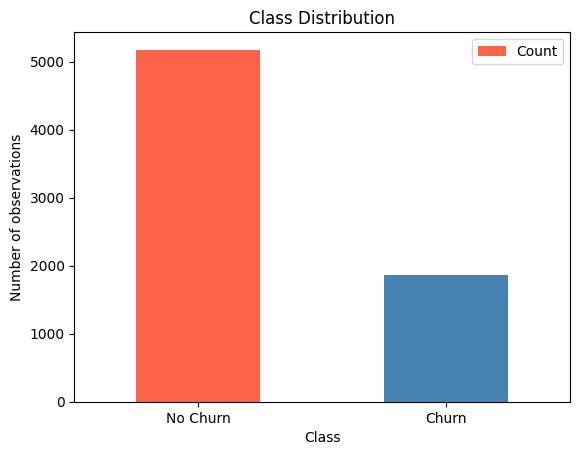

In [19]:
class_distribution.plot(
    x = "Class",
    y = "Count",
    kind = "bar",
    legend = "False",
    color = ["tomato", "steelblue"]
)

plt.ylabel("Number of observations")
plt.title("Class Distribution")
plt.xticks(rotation = 0)
plt.show()

In [20]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size = 0.20,
    random_state = 42,
    stratify = y
    )

print("Training size : ", len(y_train))
print("Testing size : ", len(y_test))

print("\nTraining Proportions : ")
print(y_train.value_counts(normalize = True).sort_index())

print("\nTesting Proportions : ")
print(y_test.value_counts(normalize = True).sort_index())

Training size :  5634
Testing size :  1409

Training Proportions : 
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64

Testing Proportions : 
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [21]:
#Train a Logistic Regression Model

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter = 1000)
)

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some 

In [22]:
#Obtain predicted probabilities

probabilities = model.predict_proba(x_test)

print(probabilities[:5])

[[0.95501784 0.04498216]
 [0.31676582 0.68323418]
 [0.94345828 0.05654172]
 [0.59219449 0.40780551]
 [0.97833433 0.02166567]]


In [23]:
print(probabilities[:5].sum(axis = 1))

[1. 1. 1. 1. 1.]


In [24]:
results = pd.DataFrame({
    "Actual_label" : y_test.values,
    "P_no_churn" : probabilities[:, 0],
    "P_churn" : probabilities[:, 1]
})

print(results.head(10))


   Actual_label  P_no_churn   P_churn
0             0    0.955018  0.044982
1             0    0.316766  0.683234
2             0    0.943458  0.056542
3             0    0.592194  0.407806
4             0    0.978334  0.021666
5             0    0.396462  0.603538
6             0    0.548127  0.451873
7             0    0.869075  0.130925
8             0    0.997148  0.002852
9             1    0.605855  0.394145


In [25]:
results

,Actual_label,P_no_churn,P_churn
0,0,0.955018,0.044982
1,0,0.316766,0.683234
2,0,0.943458,0.056542
3,0,0.592194,0.407806
4,0,0.978334,0.021666
...,...,...,...
1404,0,0.962823,0.037177
1405,0,0.982122,0.017878
1406,0,0.846881,0.153119
1407,0,0.995619,0.004381


In [26]:
threshold = 0.50

results["Predicted_churn"] = (
    results["P_churn"] >= threshold). astype(int)

results["Predicted_label"] = results[
    "Predicted_churn"
].map({
    0 : "No Churn",
    1 : "Churn"
})

print(
    results[
        [
            "Actual_label",
            "P_churn",
            "Predicted_label"
        ]
    ].head(10)
)


   Actual_label   P_churn Predicted_label
0             0  0.044982        No Churn
1             0  0.683234           Churn
2             0  0.056542        No Churn
3             0  0.407806        No Churn
4             0  0.021666        No Churn
5             0  0.603538           Churn
6             0  0.451873        No Churn
7             0  0.130925        No Churn
8             0  0.002852        No Churn
9             1  0.394145        No Churn


In [27]:
for threshold in [0.30, 0.50, 0.70]:
    predcitions = (
        results["P_churn"] >= threshold
    ).astype(int)
    
    print(
        f"Threshold = {threshold} : "
        f"Predicted Churn cases = {predcitions.sum()}"
    )

Threshold = 0.3 : Predicted Churn cases = 543
Threshold = 0.5 : Predicted Churn cases = 322
Threshold = 0.7 : Predicted Churn cases = 89


In [28]:
actual_churn = (y_test.values == 0).astype(int)

for threshold in [0.30, 0.50, 0.70]:
    predicted_churn = (
        probabilities[:, 0] >= threshold
    ).astype(int)
    
    cm = confusion_matrix(
        actual_churn,
        predicted_churn
    )
    
    print(f"\nThreshold = {threshold}")
    print(cm)


Threshold = 0.3
[[  65  309]
 [  24 1011]]

Threshold = 0.5
[[212 162]
 [110 925]]

Threshold = 0.7
[[282  92]
 [261 774]]


In [29]:
y_pred = model.predict(x_test)

from sklearn.metrics import(
    accuracy_score,
    precision_score,
    recall_score,
    f1_score   
)

print("Sklearn accuracy : ")
print(accuracy_score(y_test, y_pred)*100, "\n")

print("Sklearn precision : ")
print(precision_score(y_test, y_pred)*100, "\n")

print("Sklearn recall : ")
print(recall_score(y_test, y_pred)*100, "\n")

print("Sklearn f1_score : ")
print(f1_score(y_test, y_pred)*100, "\n")





Sklearn accuracy : 
80.69552874378992 

Sklearn precision : 
65.83850931677019 

Sklearn recall : 
56.68449197860963 

Sklearn f1_score : 
60.91954022988506 



In [ ]:
metric_results = []

for threshold in [0.10, 0.30, 0.50, 0.70, 0.90]:
    y_pred_threshold = (
        probabilities[:, 1] >= threshold
    ).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(
        y_test,
        y_pred_threshold,
        labels = [0,1]).ravel()
    
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    
    f1 = (
        2*precision * sensitivity /
        (precision + sensitivity)
        if (precision + sensitivity) > 0
        else 0
    )
    
    metric_results.append({
        "Threshold" : threshold,
        "TN" : tn,
        "FP" : fp,
        "FN" : fn,
        "TP" : tp,
        "Accuracy" : accuracy,
        "Precision" : precision,
        "Sensitivity_Recall" : sensitivity,
        "Specificity" : specificity,
        "F1_score" : f1
    })
    
threshold_metrics = pd.DataFrame(metric_results)
    
display(
    threshold_metrics.round(3)
)
    

,Threshold,TN,FP,FN,TP,Accuracy,Precision,Sensitivity_Recall,Specificity,F1_score
0,0.1,518,517,20,354,0.619,0.406,0.947,0.500,0.569
1,0.3,774,261,92,282,0.749,0.519,0.754,0.748,0.615
2,0.5,925,110,162,212,0.807,0.658,0.567,0.894,0.609
3,0.7,1011,24,309,65,0.764,0.730,0.174,0.977,0.281
4,0.9,1035,0,374,0,0.735,0.000,0.000,1.000,0.000


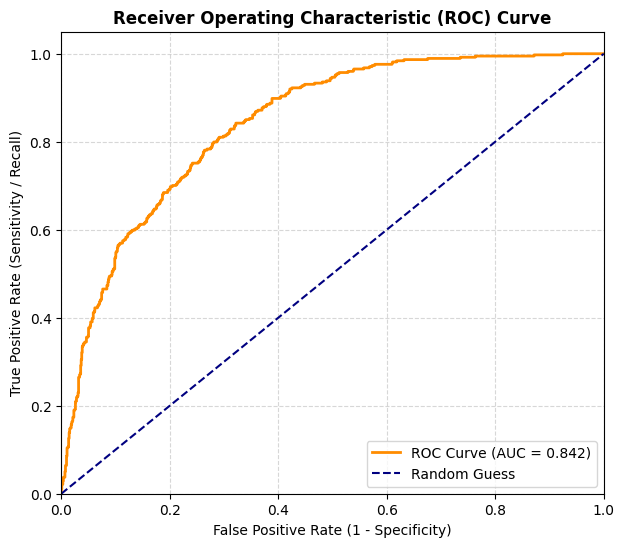

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt


fpr, tpr, thresholds = roc_curve(y_test, probabilities[:, 1])
auc_score = roc_auc_score(y_test, probabilities[:, 1])

plt.figure(figsize=(7, 6))
plt.plot(
    fpr, 
    tpr, 
    color='darkorange', 
    lw=2, 
    label=f'ROC Curve (AUC = {auc_score:.3f})'
)

plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guess')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve', fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()
